resim 1.jpeg başarıyla eşitlendi -> /content/esitlenmis_resim 1.jpeg
resim 2.jpeg başarıyla eşitlendi -> /content/esitlenmis_resim 2.jpeg


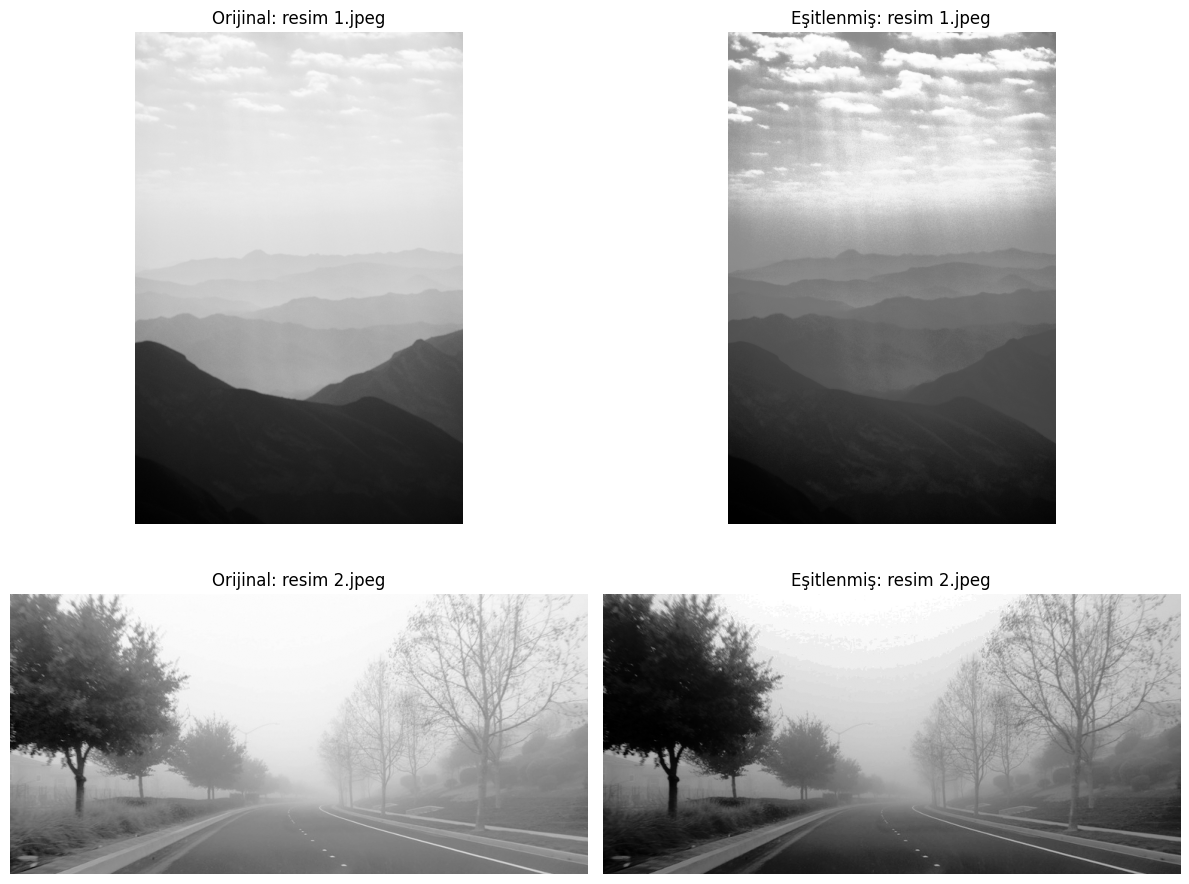

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def custom_histogram_equalization(image):
    """Hazır fonksiyon kullanmadan histogram eşitleme yapar."""
    height, width = image.shape
    total_pixels = height * width

    # 1. Histogram Hesaplama
    histogram = [0] * 256
    for r in range(height):
        for c in range(width):
            histogram[int(image[r, c])] += 1

    # 2. CDF Hesaplama
    cdf = [0] * 256
    cumulative_sum = 0
    for i in range(256):
        cumulative_sum += histogram[i]
        cdf[i] = cumulative_sum

    # cdf_min bulma
    cdf_min = 0
    for val in cdf:
        if val > 0:
            cdf_min = val
            break

    # 3. LUT Tablosu
    lut = [0] * 256
    denominator = total_pixels - cdf_min
    if denominator > 0:
        for i in range(256):
            if cdf[i] >= cdf_min:
                mapped = ((cdf[i] - cdf_min) / denominator) * 255.0
                lut[i] = int(mapped + 0.5)
            else:
                lut[i] = 0
    else:
        for i in range(256):
            lut[i] = i

    # 4. Piksel Dönüşümü
    equalized = np.zeros((height, width), dtype=np.uint8)
    for r in range(height):
        for c in range(width):
            equalized[r, c] = lut[int(image[r, c])]

    return equalized

# Colab'de dosyanın kök veya /content dizininde olma durumuna göre dosya yolu bulucu
def find_image_path(filename):
    possible_paths = [
        f"/{filename}",
        f"/content/{filename}",
        filename
    ]
    for p in possible_paths:
        if os.path.exists(p):
            return p
    return None

images_to_process = ["resim 1.jpeg", "resim 2.jpeg"]

# Görselleri ekranda 2 satır 2 sütun halinde göstermek için grafik alanı
plt.figure(figsize=(12, 10))

for idx, img_name in enumerate(images_to_process):
    img_path = find_image_path(img_name)
    if img_path is None:
        print(f"Uyarı: {img_name} Colab sol paneline henüz yüklenmemiş!")
        continue

    # Grayscale olarak oku
    orig_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if orig_img is None:
        continue

    # Eşitle
    eq_img = custom_histogram_equalization(orig_img)

    # Diske kaydet
    out_path = f"/content/esitlenmis_{img_name}"
    cv2.imwrite(out_path, eq_img)
    print(f"{img_name} başarıyla eşitlendi -> {out_path}")

    # Ekrana çiz
    # Orijinal
    plt.subplot(2, 2, idx * 2 + 1)
    plt.imshow(orig_img, cmap="gray")
    plt.title(f"Orijinal: {img_name}")
    plt.axis("off")

    # Eşitlenmiş
    plt.subplot(2, 2, idx * 2 + 2)
    plt.imshow(eq_img, cmap="gray")
    plt.title(f"Eşitlenmiş: {img_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()